k Mean clustering algo

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
 x,y = make_blobs(n_samples=1000, centers=3 , n_features=2)

In [3]:
x

array([[ -9.23829034,   4.10200924],
       [-11.92223266,   5.65483863],
       [  2.95266004,   6.93422462],
       ...,
       [  1.5734136 ,   6.81563249],
       [ -4.86516984,   2.37956312],
       [  2.49039748,   7.7738062 ]], shape=(1000, 2))

In [4]:
y

array([0, 0, 1, 1, 0, 0, 1, 2, 0, 1, 0, 0, 1, 1, 2, 2, 2, 1, 0, 0, 2, 1,
       0, 2, 2, 2, 1, 1, 0, 1, 2, 0, 2, 1, 0, 1, 2, 0, 0, 2, 0, 1, 0, 2,
       0, 2, 1, 0, 2, 1, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 1, 0, 2, 0, 2, 2,
       1, 0, 2, 0, 1, 0, 2, 0, 2, 1, 2, 2, 0, 1, 0, 1, 0, 2, 1, 0, 2, 2,
       0, 0, 1, 2, 1, 2, 1, 0, 0, 0, 2, 2, 2, 0, 0, 2, 0, 0, 1, 1, 0, 1,
       0, 2, 1, 0, 0, 1, 0, 0, 0, 2, 2, 2, 1, 0, 0, 2, 2, 2, 2, 1, 0, 0,
       2, 2, 0, 0, 1, 2, 2, 0, 1, 2, 2, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 1, 0, 2, 1, 2, 0, 1, 2, 2, 1, 1, 0, 2, 2, 1, 1,
       2, 2, 0, 1, 1, 2, 0, 2, 2, 2, 1, 0, 0, 2, 1, 0, 2, 0, 2, 1, 0, 0,
       1, 0, 0, 2, 2, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 2, 1, 1, 0, 0, 0, 2,
       1, 2, 1, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 1, 1, 1, 2,
       2, 0, 2, 1, 2, 0, 0, 2, 2, 1, 2, 2, 0, 0, 1, 0, 0, 2, 1, 1, 1, 0,
       0, 0, 2, 0, 0, 0, 2, 1, 0, 0, 1, 2, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2,
       1, 2, 1, 2, 2, 1, 2, 1, 0, 0, 2, 1, 1, 1, 2,

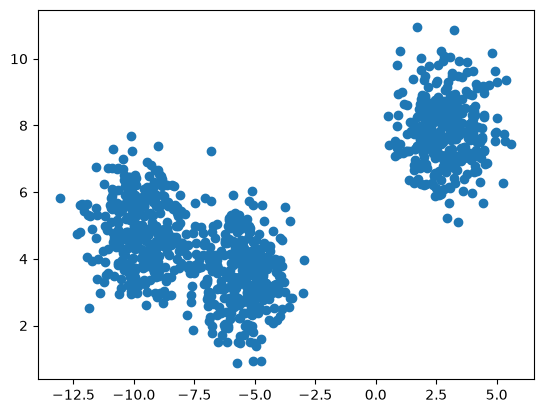

In [5]:
plt.scatter(x[: , 0] , x[: , 1] )

In [27]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y , train_size=0.20 , random_state=42)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [29]:
from sklearn.cluster import KMeans
#FOR FINDING THRU Elbow method and later will do it with silhoutte and   much more

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k , init="k-means++")
    kmeans.fit(x_train_scaled)
    wcss.append(kmeans.inertia_)

In [30]:
wcss

[400.00000000000006,
 93.84095664972443,
 50.152080796129844,
 39.734407648953514,
 29.588233031194793,
 21.072452589804534,
 18.578814585719496,
 15.418711419003031,
 14.514120444153354,
 12.837256406972683]

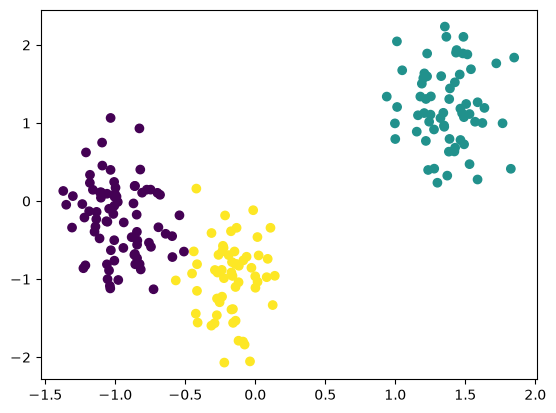

In [31]:
plt.scatter(x_train_scaled[: , 0] , x_train_scaled[: , 1] , c = y_train )


NameError: name 'plot' is not defined

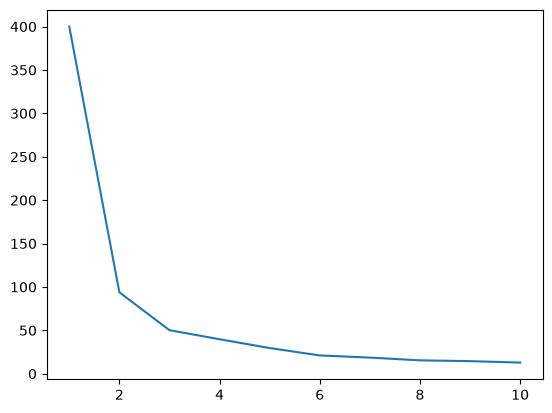

In [32]:
#plot elbow curve
plt.plot(range(1,11) , wcss)
plot.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("wcss")
plt.show()

In [33]:
kmeans = KMeans(n_clusters=3 , init="k-means++")
kmeans.fit_predict(x_train_scaled)

array([1, 2, 1, 1, 2, 0, 1, 0, 2, 1, 2, 1, 0, 0, 2, 1, 1, 0, 2, 2, 1, 0,
       0, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 0, 1, 0, 1, 2, 0,
       2, 2, 0, 1, 0, 2, 0, 1, 1, 2, 2, 1, 0, 2, 2, 2, 0, 1, 2, 1, 1, 0,
       0, 0, 0, 0, 2, 0, 1, 0, 2, 1, 0, 1, 0, 0, 2, 0, 2, 0, 1, 2, 2, 2,
       2, 2, 2, 1, 0, 2, 2, 1, 0, 1, 1, 0, 1, 2, 0, 0, 2, 0, 2, 0, 2, 1,
       0, 0, 2, 0, 1, 2, 1, 0, 1, 0, 2, 0, 1, 0, 1, 1, 1, 0, 2, 2, 2, 0,
       2, 0, 1, 2, 2, 0, 2, 1, 0, 1, 1, 2, 1, 0, 2, 1, 2, 2, 1, 2, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 2, 2, 0, 1, 0, 2, 1, 2, 2, 2, 1, 0, 2, 0,
       0, 2, 1, 1, 2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 2, 2, 1, 0, 1,
       0, 2], dtype=int32)

In [19]:
y_pred = kmeans.predict(x_train_scaled)

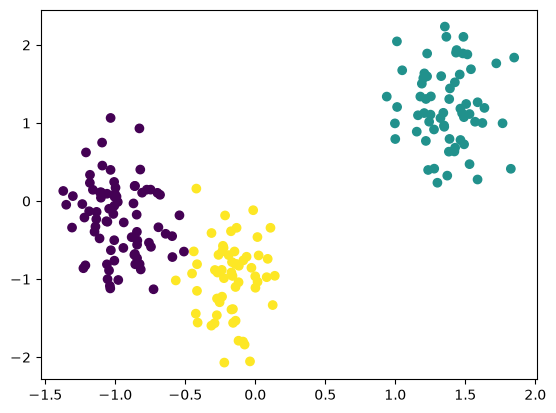

In [34]:
plt.scatter(x_train_scaled[: , 0] , x_train_scaled[: , 1] , c = y_train )


but sometimes it became difficult to tell the elbow so we use 
some method for Validating the k values

# kneelocator

# silhoutte clustering algo(or scoring)

In [ ]:
#kneelocater
from kneed import KneeLocator


In [46]:
k1 = KneeLocator(range(1,11) , wcss ,curve="convex" ,  direction = "decreasing")

In [47]:
k1.elbow

np.int64(3)

In [50]:
#silhoutte scoring
from sklearn.metrics import silhouette_score

silhouette_coefficients = []
for k in range(1,11):
    kmeans = KMeans(n_clusters= k , init="k-means++")
    kmeans.fit(x_train_scaled)
    #score = silhouette_score(x_train_scaled ,kmeans.labels_)
    
    

In [53]:
score = silhouette_score(x_train_scaled ,kmeans.labels_)
silhouette_coefficients.append(score)

In [54]:
silhouette_coefficients

[0.4087458315120785]